# 🏪 Notebook 06 — Análise e Segmentação de Vendedores (Olist)

**Objetivo:** Analisar a base de vendedores (sellers), a concentração de receita (Curva de Pareto e Coeficiente de Gini), métricas de qualidade e especialização por categoria.

## 1. Importações e Configurações

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Detecção dinâmica de caminhos para dados e outputs
DATA_DIR = '../data/olist' if os.path.exists('../data/olist') else 'data/olist'
if not os.path.exists(DATA_DIR):
    DATA_DIR = '/home/jorge/Documents/tech-challenge-agentes-ia/data/olist'

OUTPUT_DIR = './outputs' if os.path.exists('./outputs') or os.path.basename(os.getcwd()) == 'notebooks' else 'notebooks/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"📁 Diretório de Dados: {os.path.abspath(DATA_DIR)}")
print(f"📁 Diretório de Outputs: {os.path.abspath(OUTPUT_DIR)}")


📁 Diretório de Dados: /home/jorge/Documents/tech-challenge-agentes-ia/data/olist
📁 Diretório de Outputs: /home/jorge/Documents/tech-challenge-agentes-ia/notebooks/outputs


## 2. Carregamento e Preparação dos Dados

In [2]:
sellers = pd.read_csv(os.path.join(DATA_DIR, 'olist_sellers_dataset.csv'))
items = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_items_dataset.csv'))
orders = pd.read_csv(os.path.join(DATA_DIR, 'olist_orders_dataset.csv'))
reviews = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_reviews_dataset.csv'))
products = pd.read_csv(os.path.join(DATA_DIR, 'olist_products_dataset.csv'))
trans = pd.read_csv(os.path.join(DATA_DIR, 'product_category_name_translation.csv'))

items_full = items.merge(orders, on='order_id').merge(reviews, on='order_id', how='left')
print(f"✓ Total de itens de vendas por vendedores: {items_full.shape[0]}")


✓ Total de itens de vendas por vendedores: 113314


## 3. Visão Geral da Base de Vendedores

🏪 Total de Vendedores Cadastrados: 3095
🛒 Vendedores Ativos (Com Pelo Menos 1 Venda): 3095


/tmp/ipykernel_110473/1028043439.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sellers_by_state.head(10).index, y=sellers_by_state.head(10).values, palette='mako')


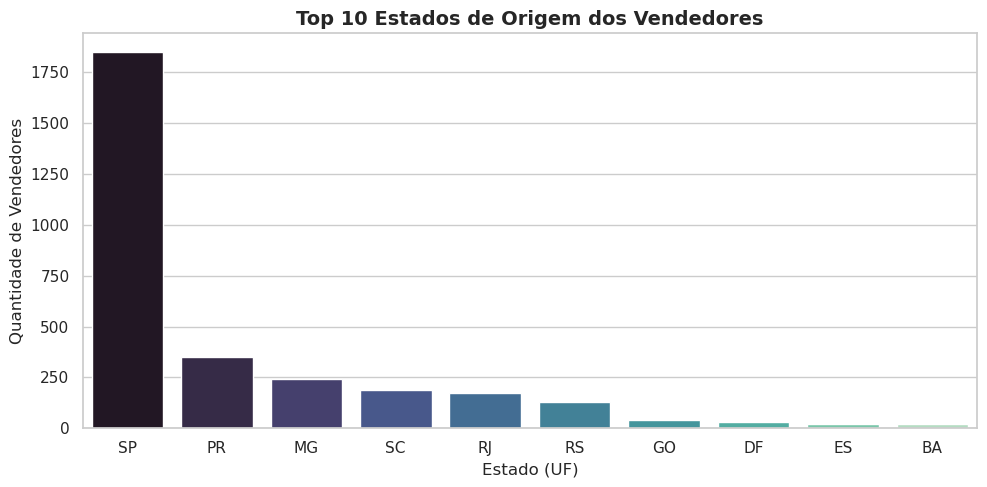

In [3]:
total_sellers = len(sellers)
sellers_with_sales = items['seller_id'].nunique()
sellers_by_state = sellers['seller_state'].value_counts()

print(f"🏪 Total de Vendedores Cadastrados: {total_sellers}")
print(f"🛒 Vendedores Ativos (Com Pelo Menos 1 Venda): {sellers_with_sales}")

plt.figure(figsize=(10, 5))
sns.barplot(x=sellers_by_state.head(10).index, y=sellers_by_state.head(10).values, palette='mako')
plt.title('Top 10 Estados de Origem dos Vendedores', fontsize=14, fontweight='bold')
plt.xlabel('Estado (UF)')
plt.ylabel('Quantidade de Vendedores')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_sellers_by_state.png'))
plt.show()


## 4. Análise de Pareto e Concentração de Receita (Gini)

In [4]:
seller_revenue = items.groupby('seller_id')['price'].sum().sort_values(ascending=False)

# Curva acumulada
total_rev = seller_revenue.sum()
cum_rev = seller_revenue.cumsum() / total_rev * 100
cum_sellers = (np.arange(1, len(seller_revenue) + 1) / len(seller_revenue)) * 100

top_80_sellers_pct = (seller_revenue[cum_rev <= 80].count() / len(seller_revenue)) * 100

# Coeficiente de Gini
def gini(array):
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

gini_score = gini(seller_revenue.values)

print(f"📈 PARETO: Apenas {top_80_sellers_pct:.1f}% dos vendedores geram 80% de toda a receita da Olist!")
print(f"📊 Coeficiente de Gini da Receita dos Sellers: {gini_score:.3f} (Altíssima concentração de mercado)")


📈 PARETO: Apenas 17.5% dos vendedores geram 80% de toda a receita da Olist!
📊 Coeficiente de Gini da Receita dos Sellers: 0.792 (Altíssima concentração de mercado)


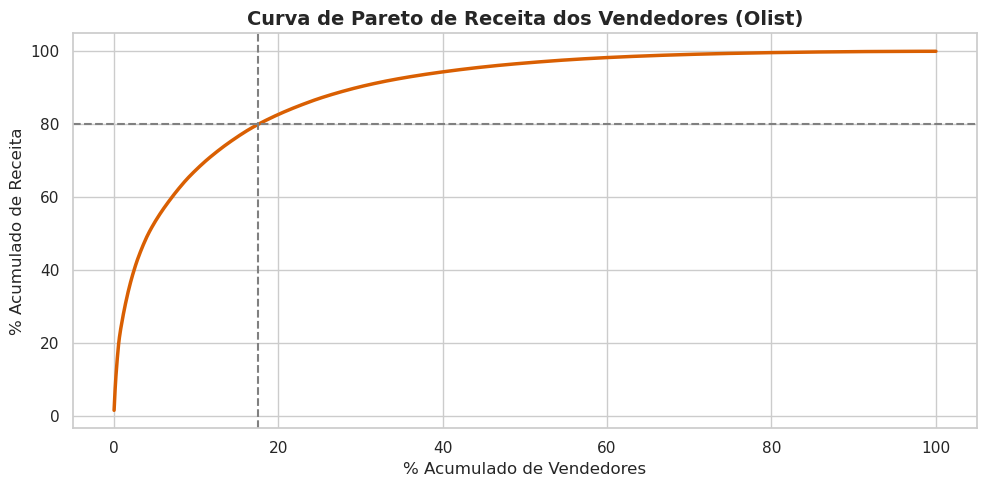

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(cum_sellers, cum_rev, color='#d95f02', linewidth=2.5)
plt.axhline(80, color='gray', linestyle='--')
plt.axvline(top_80_sellers_pct, color='gray', linestyle='--')
plt.title('Curva de Pareto de Receita dos Vendedores (Olist)', fontsize=14, fontweight='bold')
plt.xlabel('% Acumulado de Vendedores')
plt.ylabel('% Acumulado de Receita')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_pareto_curve.png'))
plt.show()


## 5. Qualidade e Avaliação Média por Vendedor

⚠️ Vendedores com Nota Média < 3.0: 342 (11.1%)


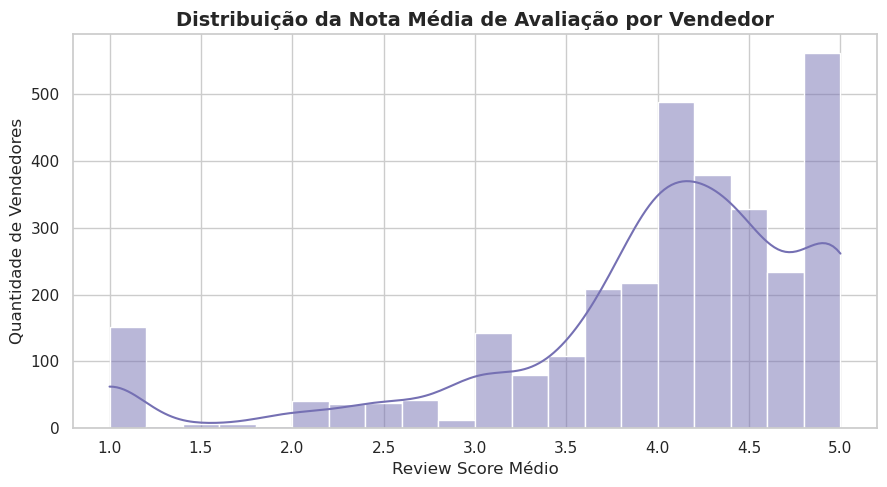

In [6]:
seller_metrics = items_full.groupby('seller_id').agg(
    total_receita=('price', 'sum'),
    total_pedidos=('order_id', 'nunique'),
    review_medio=('review_score', 'mean')
).reset_index()

low_score_sellers = (seller_metrics['review_medio'] < 3.0).sum()
print(f"⚠️ Vendedores com Nota Média < 3.0: {low_score_sellers} ({ (low_score_sellers/len(seller_metrics))*100:.1f}%)")

plt.figure(figsize=(9, 5))
sns.histplot(seller_metrics['review_medio'], bins=20, kde=True, color='#7570b3')
plt.title('Distribuição da Nota Média de Avaliação por Vendedor', fontsize=14, fontweight='bold')
plt.xlabel('Review Score Médio')
plt.ylabel('Quantidade de Vendedores')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_seller_avg_reviews.png'))
plt.show()


## 6. Especialização por Categoria

In [7]:
items_cat = items.merge(products, on='product_id')
seller_cats = items_cat.groupby('seller_id')['product_category_name'].nunique()

specialists = (seller_cats == 1).sum()
generalists = (seller_cats > 1).sum()

print(f"🎯 Vendedores Especialistas (1 única categoria): {specialists} ({specialists/len(seller_cats)*100:.1f}%)")
print(f"🌐 Vendedores Generalistas (2+ categorias): {generalists} ({generalists/len(seller_cats)*100:.1f}%)")


🎯 Vendedores Especialistas (1 única categoria): 1728 (55.8%)
🌐 Vendedores Generalistas (2+ categorias): 1307 (42.2%)
